In [4]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

### 1. Import database/data

In [5]:
conn = sqlite3.connect('customer_churn.db')
sql_query = """
            SELECT name
            FROM sqlite_master
            WHERE type = 'table';
            """
tables = pd.read_sql(sql_query,conn)
# create dataframe for each tabel
for table_name in tables['name']:
    df=pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"created dataframe:df_{table_name}")

conn.close()

created dataframe:df_db_customer
created dataframe:df_db_subscription
created dataframe:df_db_support


In [6]:
# print table names and column names
conn = sqlite3.connect('customer_churn.db')
for table_name in tables['name']:
    print(f"\nTable Name:{table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query,conn)
    print("columns")
    print(columns['name'].tolist())


Table Name:db_customer
columns
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name:db_subscription
columns
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name:db_support
columns
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [7]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [8]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


#### Data Cleaning
#### a. rename col_name

In [9]:
df_db_customer.rename(columns={'name':'customer_name'},inplace=True)

#### b. Drop Cols - Intrest and pincode using index position & using col name


In [10]:
df_db_customer.drop(df_db_customer.columns[-2:],axis=1,inplace=True)
 #df_db_customer.drop(df_db_customer.columns['interests','pincode'],inplace=True)


#### c. change data types-dob from object to datatime

In [11]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

#### d. data standardization-gender col

In [12]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [13]:
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

In [14]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

#### e. Fix missing values country

In [15]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


# will find previous set-up for country & state filter both cols

In [16]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [17]:
#Country & state - unique Value pair
state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [18]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [19]:
# Data Cleaning For db_subscription
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


#### a.  changing datatype for subscription_start_date,renewal_date,cancellation_date from object to datetime

In [20]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [21]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [22]:
df_db_support['customerid'].nunique()

7

In [23]:
df_db_support['customerid'].count()

np.int64(9)

In [24]:
df_db_support

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,None
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,None
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,None
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [25]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')


In [26]:
df_db_support

,customerid,complaint_date,escalations,csat_score,col_1,comment,complaint_count
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue,2
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund,2
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None,1
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew,1
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None,1
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,None,1
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,None,1
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,None,2
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund,2


In [27]:
#### keep Latest Record Remove Rest
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [28]:
df_db_support.shape

(7, 7)

#### Merging all the table into a single DataFrame

In [29]:
df =  df_db_customer.merge(df_db_subscription,on='customerid',how='left').merge(df_db_support,on='customerid',how='left')

In [30]:
df.head()

,customerid,customer_name,country,state,gender,dob,subscription_start_date,subscription_type,renewal_date,plan_type,...,cancellation_reason,monthly_charges,cltv,churn_score,complaint_date,escalations,csat_score,col_1,comment,complaint_count
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,2021-03-15,Refferal,2025-03-15,Standard,...,None,13.99,627,12,NaN,NaN,NaN,NaN,NaN,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,2020-08-01,Paid,2024-08-01,Premium,...,Switched to competitor,12.99,1150,91,2024-08-28 00:00:00,Y,10.0,None,demaned refund,2.0
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,2022-11-20,Organic,2025-11-20,Basic,...,None,6.99,210,34,NaN,NaN,NaN,NaN,NaN,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,2019-05-10,Paid,2025-05-10,Premium,...,None,22.99,1725,8,NaN,NaN,NaN,NaN,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,2023-01-05,Refferal,2024-01-05,Standard,...,Too expensive,13.99,195,88,2024-01-20 00:00:00,Y,20.0,None,None,1.0


In [31]:
df.shape

(21, 22)

In [32]:
df.drop(columns=['col_1','comment'],inplace=True)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   customer_name            21 non-null     object        
 2   country                  21 non-null     object        
 3   state                    21 non-null     object        
 4   gender                   21 non-null     object        
 5   dob                      21 non-null     datetime64[ns]
 6   subscription_start_date  21 non-null     datetime64[ns]
 7   subscription_type        21 non-null     object        
 8   renewal_date             21 non-null     datetime64[ns]
 9   plan_type                21 non-null     object        
 10  contract_type            21 non-null     object        
 11  cancellation_date        6 non-null      datetime64[ns]
 12  cancellation_reason      6 non-null   

In [34]:
df['complaint_date'] = pd.to_datetime(df['complaint_date'])

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   customer_name            21 non-null     object        
 2   country                  21 non-null     object        
 3   state                    21 non-null     object        
 4   gender                   21 non-null     object        
 5   dob                      21 non-null     datetime64[ns]
 6   subscription_start_date  21 non-null     datetime64[ns]
 7   subscription_type        21 non-null     object        
 8   renewal_date             21 non-null     datetime64[ns]
 9   plan_type                21 non-null     object        
 10  contract_type            21 non-null     object        
 11  cancellation_date        6 non-null      datetime64[ns]
 12  cancellation_reason      6 non-null   

#### 3. Feature Engineering and Data Analysis

In [36]:
# Adding new Column from existing column
df['churn flag'] = np.where(df['cancellation_date'].notna(),1,0)

In [37]:
df.shape

(21, 21)

In [38]:
# Exporting data 
df.to_csv('churn_data.csv',index=False)

### Data Analysis 
#### 1. Churn Rate

In [39]:
churn_rate = df['churn flag'].mean()*100
print("churn rate = ",round(churn_rate,2),"%")

churn rate =  28.57 %


#### 2. Retention Rate


In [40]:
retention_rate = 100-churn_rate
print("retention rate = ",round(retention_rate,2),"%")

retention rate =  71.43 %


#### 3. Churn By Plan Type

In [41]:
churn_by_plan = (df.groupby('plan_type')['churn flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


#### 4. Churn By State 


In [79]:
churn_by_state = df_visual.groupby('state')['churn flag'].mean()
print(f"churn_by_state:'{round(churn_by_state),2}'")

state
Delhi            0.250000
Karnataka        1.000000
Kathmandu        0.000000
Maharashtra      0.000000
Meghalaya        0.666667
Nagaland         0.000000
Rajasthan        0.000000
Telangana        0.500000
Uttar Pradesh    0.000000
Name: churn flag, dtype: float64


#### 5. ARPU(avg revenue per user)

In [42]:
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


#### 6. Avg Customer Tenure

In [43]:
# count of Days users has used our services : cancellation date else current date
today = pd.Timestamp.today()


df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (pd.Timestamp('today') - df['subscription_start_date']).dt.days
)
avg_tenure = df['tenure_days'].mean()
print("Avg Tenure(Days) = ",round(avg_tenure),0)

Avg Tenure(Days) =  1547 0


#### 7. Revenue at Risk

In [44]:
# Revenue Lost from churned
revenue_at_risk = df.loc[df['churn flag']==1,'monthly_charges'].sum()
print("Revenue at Risk (RS 'K') = ",revenue_at_risk)

Revenue at Risk (RS 'K') =  73.94


#### 8. Esclation Rate

In [45]:
escalation_rate = (df['escalations'] == 'Y').mean()*100
print("Esclation Rate ",round(escalation_rate,2),"%")

Esclation Rate  19.05 %


#### 9. Avg Complaint per user

In [46]:
avg_complaints = df['complaint_count'].sum()/df['customerid'].nunique()
print("Avg Complaints per user = ",round(avg_complaints,2))

Avg Complaints per user =  0.43


#### 10. Correlation Esclation Vs Churn

In [47]:
# 1. Map string column to integer (using pandas map)
df['escalations'] = df['escalations'].map({'Y': 1, 'N': 0})

# 2. Calculate correlation directly (pandas automatically ignores NaN values)
correlation = df['escalations'].corr(df['churn flag'])

print("Correlation b/w escalation vs churn is =", round(correlation, 2))


Correlation b/w escalation vs churn is = 0.47


#### 11. churn risk - create a column using existing col

In [66]:
import numpy as np

conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unknown')


### Step-4 Visualization using matplotlib

In [69]:
df_visual = df.copy()

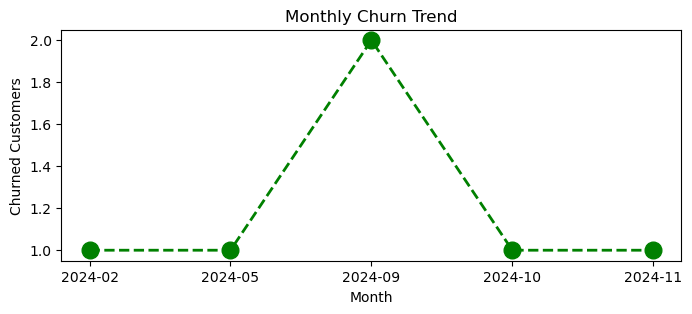

In [70]:
# 4.1 Monthly Churn Trend (Time series KPI)
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8, 3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, 
         color='green', marker='o', linestyle='dashed', 
         linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

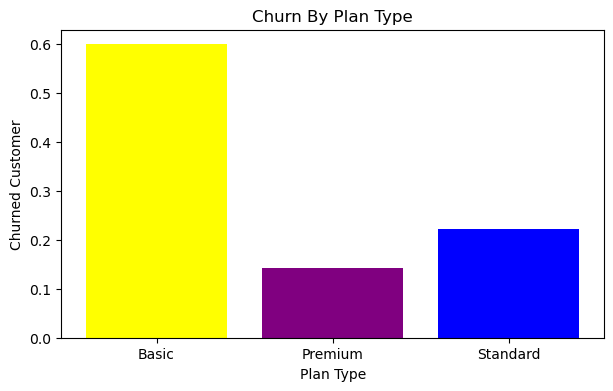

In [71]:
# 4.2 Churn by Plan Type
churn_plan = df_visual.groupby('plan_type')['churn flag'].mean()
# to make dynamic colors 
#colors = plt.on set2(np.linespace(0,1,len(churn_plan)))
colors = ['yellow','purple','blue']
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values,color = colors)
plt.title('Churn By Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churned Customer')
plt.show()

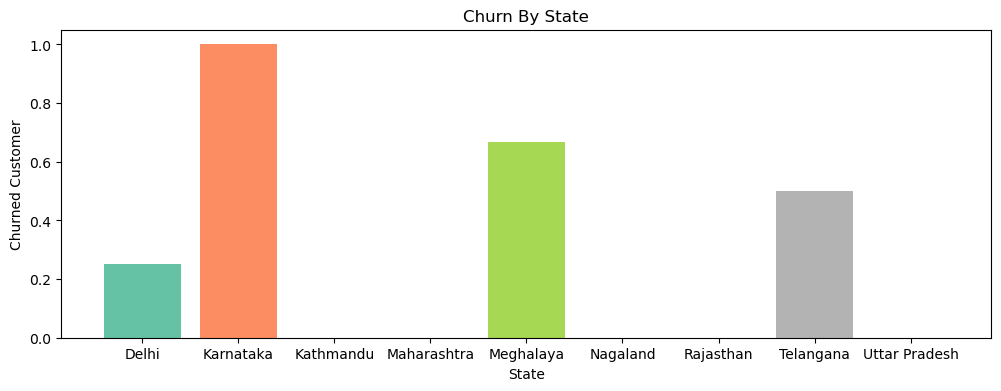

In [72]:
# 4.3 Churn by State
churn_state = df_visual.groupby('state')['churn flag'].mean()
# Corrected line
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_state)))

plt.figure(figsize=(12,4))
plt.bar(churn_state.index,churn_state.values,color = colors)
plt.title('Churn By State')
plt.xlabel('State')
plt.ylabel('Churned Customer')
plt.show()

#### Visulazation using Seaborn

In [76]:
import warnings
warnings.filterwarnings("ignore")

In [77]:
# 4.4 Heatmap(correlation matrix)
# encoding - convert str to numeric so that we can find corr b/w features
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn flag','churn_risk','escalations']]
order_mapping ={
            'plan_type' : ['Basic','Standard','Premiun'],
            'contract_type' : ['Monthly','Anually'],
            'churn_risk' : ['low','med','high']
}
for col,order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col], categories=order, ordered=True).codes



<Axes: >

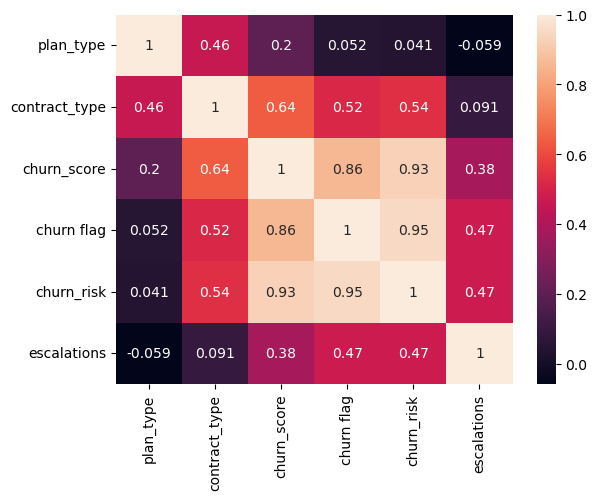

In [78]:
#Heatmap(correlation matrix)
sns.heatmap(df_encoded.corr(),annot = True)

In [70]:
df.columns

Index(['customerid', 'customer_name', 'country', 'state', 'gender', 'dob',
       'subscription_start_date', 'subscription_type', 'renewal_date',
       'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn flag'],
      dtype='object')